In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator

In [2]:
import pandas as pd
df = pd.read_csv(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\CadenceGraphs\TDC_INL_DNL_TT.csv")
data_TT = df["C0"][15::15]
df = pd.read_csv(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\CadenceGraphs\TDC_INL_DNL_FF.csv")
data_FF = df["C1"][15::15]
df = pd.read_csv(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\CadenceGraphs\TDC_INL_DNL_SS.csv")
data_SS = df["C2"][15::15]
print(len(list(data_TT)))



2561


C:\Users\91880\AppData\Local\Temp\ipykernel_45928\416026895.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
def get_inl_dnl(data):
    num_codes = 256
    ideal_hits = 10.0
    counts = np.bincount(data, minlength=num_codes)
    print(list(counts))
    counts[0] = 20
    #counts[255] = 9
    DNL = counts / ideal_hits - 1.0

    N = len(DNL)
    k = np.arange(N)

    # ---- Raw INL (no endpoint correction) ----
    INL_raw = np.zeros(N)
    INL_raw[1:] = np.cumsum(DNL[:-1])
    poly_coeff = np.polyfit(k, INL_raw, 1)
    poly_fit = np.polyval(poly_coeff, k)
    INL = INL_raw - poly_fit
    #INL_raw = np.zeros(num_codes)
    #INL_raw[1:] = np.cumsum(DNL[:-1])
    
    # ---- End-point INL correction ----
    #k = np.arange(num_codes)
    #INL = INL_raw - (k / (num_codes - 1)) * INL_raw[-1]
    # ---- Sanity checks ----
    print("Mean DNL:", np.mean(DNL))
    print("Min DNL :", np.min(DNL))
    print("Max DNL :", np.max(DNL))
    print("INL end :", INL[0], INL[-1])
    return DNL,INL

In [4]:
DNL_TT, INL_TT = get_inl_dnl(data_TT)
DNL_FF, INL_FF = get_inl_dnl(data_FF)
DNL_SS, INL_SS = get_inl_dnl(data_SS)

[29, 9, 10, 11, 8, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 9, 10, 9, 10, 12, 20, 9, 10, 10, 9, 9, 11, 9, 9, 10, 9, 10, 9, 10, 10, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 9, 10, 9, 10, 12, 20, 9, 10, 10, 9, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 9, 10, 9, 10, 12, 20, 9, 10, 10, 9, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 9, 11, 8, 10, 12, 20, 9, 10, 10, 9, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 9, 11, 8, 10, 12, 20, 9, 10, 10, 9, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 10, 10, 8, 10, 12, 20, 9, 10, 11, 8, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 10, 10, 8, 10, 12, 20, 9, 10, 11, 8, 9, 11, 9, 9, 10, 9, 10, 9, 11, 9, 14, 3, 10, 10, 9, 10, 11, 9, 10, 10, 10, 10, 10, 10, 8, 10, 4]
Mean DNL: -0.0031249999999999815
Min DNL : -0.7
Max DNL : 1.0
INL end : -0.

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['xtick.labelsize'] = 9
mpl.rcParams['ytick.labelsize'] = 9
mpl.rcParams['legend.fontsize'] = 9

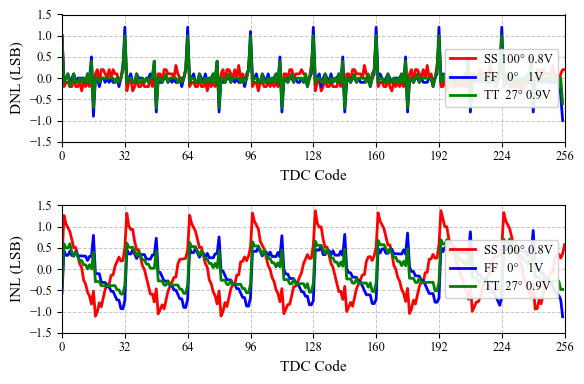

In [6]:
#fig, ax1 = plt.subplots(figsize=(4, 2))
fig, axes = plt.subplots(2, 1, figsize=(6, 4))
ax1, ax2 = axes.flatten()
# First plot (left y-axis)

ax1.plot(DNL_SS, color="r",linewidth=2, label = "SS 100° 0.8V")
ax1.plot(DNL_FF, color="b",linewidth=2, label = "FF   0°   1V")
ax1.plot(DNL_TT, color="g",linewidth=2, label = "TT  27° 0.9V")

ax2.plot(INL_SS, color="r",linewidth=2, label = "SS 100° 0.8V")
ax2.plot(INL_FF, color="b",linewidth=2, label = "FF   0°   1V")
ax2.plot(INL_TT, color="g",linewidth=2, label = "TT  27° 0.9V")

ax1.set_ylabel("DNL (LSB)")
ax1.set_ylim(-1.5, 1.5)
ax1.yaxis.set_major_locator(MultipleLocator(0.5))

ax2.set_ylabel("INL (LSB)")
ax2.set_ylim(-1.5, 1.5)
ax2.yaxis.set_major_locator(MultipleLocator(0.5))


ax1.set_xlabel("TDC Code")
ax1.set_xlim(0, 256)
ax1.xaxis.set_major_locator(MultipleLocator(32))

ax2.set_xlabel("TDC Code")
ax2.set_xlim(0, 256)
ax2.xaxis.set_major_locator(MultipleLocator(32))

ax1.legend(loc = "center right",framealpha = 0.9)
ax2.legend(loc = "center right",framealpha = 0.9)
#plt.xticks(range(0, 256*7+1,32*7)) 
# Optional: title
#fig.suptitle("TDC DNL - INL across PVT corners (Simulated)")

ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

ax2.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax2.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(r"D:\ISSCC_26\Graphs\TDC_INL_DNL.jpg", dpi=800, bbox_inches="tight")
plt.show()

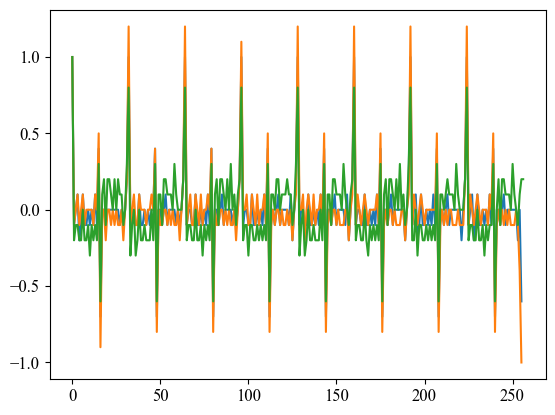

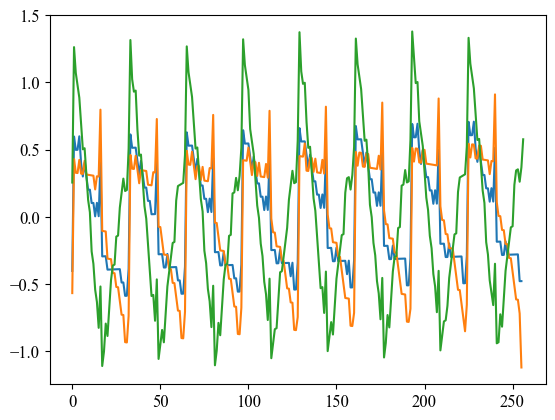

In [12]:
plt.plot(DNL_TT)
plt.plot(DNL_FF)
plt.plot(DNL_SS)
plt.show()
plt.plot(INL_TT)
plt.plot(INL_FF)
plt.plot(INL_SS)